In [2]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
FIELDVARS  = CONFIGS['experiments']['sr']['runs']['sr_atm']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
SPLIT      = 'test'
MINCUBESAMPLES = 100

SRFUNCTIONS = {
    'cube':lambda x:x**3,'square':lambda x:x**2,'neg':lambda x:-x,
    'sqrt':np.sqrt,'exp':np.exp,'log':np.log,'abs':np.abs,
    'sin':np.sin,'cos':np.cos,'max':np.maximum,'min':np.minimum,
    '_safepow':lambda a,b:np.abs(a)**b}

import re
def _prepare_form(form):
    return re.sub(r'(\w+)\^(\w+)',r'_safepow(\1,\2)',form)

def eval_form(form,columns,constants):
    ns = dict(SRFUNCTIONS,__builtins__={})
    ns.update(columns)
    ns.update(constants)
    out = eval(_prepare_form(form),ns)
    if np.ndim(out)==0:
        n = len(next(v for v in columns.values() if hasattr(v,'__len__')))
        out = np.full(n,float(out))
    return np.asarray(out,dtype=float)

In [ ]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
MEAN = STATS['tp_mean']
STD  = STATS['tp_std']
ZMIN = (0.0 - MEAN) / STD

with xr.open_dataset(os.path.join(SPLITSDIR,f'norm_{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime = ds.sizes['time']
    nsig  = ds.sizes.get('sig',1)
    dsig  = ds['dsig'].values
    fields = np.stack([ds[v].transpose('time','lat','lon','sig').values.reshape(-1,nsig) for v in FIELDVARS],axis=1)
    surfmask = ds['surfmask'].transpose('time','lat','lon','sig').values.reshape(-1,nsig) if 'surfmask' in ds else None
    flat = lambda v: ds[v].transpose('time','lat','lon').values.ravel() if 'time' in ds[v].dims else np.tile(ds[v].values,(ntime,1,1)).ravel()
    lfraw = flat('lf')
    shfraw = flat('shf')
    lhfraw = flat('lhf')
    blraw = flat('bl') if 'bl' in ds else np.zeros(ntime*ds.sizes['lat']*ds.sizes['lon'])

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds.k.values)
meankernel = np.mean(kernels,axis=0)
weighted = fields * meankernel[None,:,:] * dsig[None,None,:]
if surfmask is not None:
    weighted = weighted * surfmask[:,None,:]
integrals = weighted.sum(axis=2)
rhraw,thetaeraw,thetaestarraw = integrals[:,0],integrals[:,1],integrals[:,2]

valid = np.isfinite(rhraw) & np.isfinite(thetaeraw) & np.isfinite(thetaestarraw)
rh,thetae,thetaestar = rhraw[valid],thetaeraw[valid],thetaestarraw[valid]
lf,shf,lhf = lfraw[valid],shfraw[valid],lhfraw[valid]
bl = blraw[valid]
landmask  = lf > 0.5
oceanmask = lf < 0.5
print(f'Loaded {valid.sum():,} valid samples ({landmask.sum():,} land, {oceanmask.sum():,} ocean)')

In [5]:
regpath = os.path.join(MODELSDIR,'sr','optimized_equations.pkl')
with open(regpath,'rb') as f:
    REGISTRY = pickle.load(f)
SRMODELS = CONFIGS['experiments']['sr']['optimizedeqs']
ORDER = [name for name in SRMODELS if name in REGISTRY]
LABELS = {name:SRMODELS[name]['description'] for name in ORDER}
COLORS = {name:SRMODELS[name]['color'] for name in ORDER}
print(f'Loaded {len(ORDER)} optimized equations: {[LABELS[n] for n in ORDER]}')

Loaded 4 optimized equations: ['SR-BL', 'SR-ATM', 'SR-SFC', 'SR-ALL']


In [ ]:
def predict_eq(name,columns):
    entry = REGISTRY[name]
    form,constants = entry['form'],entry['constants']
    raw = eval_form(form,columns,constants)
    z = ZMIN + np.maximum(raw,0.0)
    return np.maximum(np.expm1(z * STD + MEAN),0.0)

def get_columns(**overrides):
    cols = {'rh':rh,'thetae':thetae,'thetaestar':thetaestar,'lf':lf,'shf':shf,'lhf':lhf,'bl':bl}
    cols.update(overrides)
    for eqname,entry in REGISTRY.items():
        if eqname in overrides:
            continue
        cols[eqname] = eval_form(entry['form'],cols,entry['constants'])
    return cols

In [7]:
BASEVARS = ['rh','thetae','thetaestar','lf','shf','lhf','bl']

def cube_monotonicity_test(name,target_var,expected_sign,other_vars,ncubes,mask=None):
    '''
    Grundner et al. (2024) cube-based monotonicity test.

    Divides the space of `other_vars` into ncubes^len(other_vars) hypercubes.
    Within each cube, fits a linear slope of P w.r.t. `target_var`.
    Returns the fraction of cubes where the slope has the expected sign.
    '''
    cols = get_columns()
    targetvals = cols[target_var]
    othervalslist = [cols[v] for v in other_vars]
    nother = len(other_vars)

    if mask is None:
        mask = np.ones(len(targetvals),dtype=bool)

    edges = [np.linspace(np.percentile(v[mask],1),np.percentile(v[mask],99),ncubes+1) for v in othervalslist]
    bins  = [np.clip(np.digitize(v,e)-1,0,ncubes-1) for v,e in zip(othervalslist,edges)]

    nsatisfied = 0
    ntested = 0

    cubeidx = bins[0].copy()
    for i in range(1,nother):
        cubeidx = cubeidx * ncubes + bins[i]

    for cidx in range(ncubes**nother):
        sel = mask & (cubeidx == cidx)
        if sel.sum() < MINCUBESAMPLES:
            continue

        nsel = sel.sum()
        x = targetvals[sel]
        overrides = {k:cols[k][sel] for k in BASEVARS}
        overrides[target_var] = x
        for v,binarr,edgearr in zip(other_vars,bins,edges):
            ci = cidx
            for j in range(nother-1,-1,-1):
                if other_vars[j] == v:
                    bi = ci % ncubes
                    break
                ci //= ncubes
            midpoint = 0.5 * (edgearr[bi] + edgearr[bi+1])
            overrides[v] = np.full(nsel,midpoint)

        cubecols = get_columns(**overrides)
        p = predict_eq(name,cubecols)

        if len(x) < 2:
            continue
        xc = x - x.mean()
        slope = np.dot(xc,p) / (np.dot(xc,xc) + 1e-12)

        ntested += 1
        if expected_sign >= 0 and slope >= 0:
            nsatisfied += 1
        elif expected_sign < 0 and slope <= 0:
            nsatisfied += 1

    return nsatisfied,ntested

In [8]:
CONSTRAINTS = {
    'PC3':{  
        'label':r'$\partial P/\partial \widehat{\mathrm{RH}} \geq 0$',
        'target_var':'rh',
        'expected_sign':1,
        'other_vars':['thetae','thetaestar']},
    'PC4':{
        'label':r'$\partial P/\partial \widehat{\theta_e} \geq 0$',
        'target_var':'thetae',
        'expected_sign':1,
        'other_vars':['rh','thetaestar']},
    'PC5':{
        'label':r'$\partial P/\partial \widehat{\theta_e^*} \leq 0$',
        'target_var':'thetaestar',
        'expected_sign':-1,
        'other_vars':['rh','thetae']}}

NCUBES = [3,4,5,6,7]
print(f'Testing {len(CONSTRAINTS)} constraints across {len(NCUBES)} cube sizes')

Testing 3 constraints across 5 cube sizes


In [9]:
results = {}
for name in ORDER:
    results[name] = {}
    print(f'\n{LABELS[name]}:')
    for pcname,pc in CONSTRAINTS.items():
        results[name][pcname] = {'all':{},'land':{},'ocean':{}}
        for n in NCUBES:
            sat,tot = cube_monotonicity_test(name,pc['target_var'],pc['expected_sign'],pc['other_vars'],n)
            results[name][pcname]['all'][n] = (sat,tot)
            sat_l,tot_l = cube_monotonicity_test(name,pc['target_var'],pc['expected_sign'],pc['other_vars'],n,mask=landmask)
            results[name][pcname]['land'][n] = (sat_l,tot_l)
            sat_o,tot_o = cube_monotonicity_test(name,pc['target_var'],pc['expected_sign'],pc['other_vars'],n,mask=oceanmask)
            results[name][pcname]['ocean'][n] = (sat_o,tot_o)
        avg_all = np.mean([results[name][pcname]['all'][n][0]/max(results[name][pcname]['all'][n][1],1)*100 for n in NCUBES])
        print(f'  {pcname} ({pc["label"]}): {avg_all:.1f}% average satisfaction')


SR-BL:
  PC3 ($\partial P/\partial \widehat{\mathrm{RH}} \geq 0$): 53.9% average satisfaction
  PC4 ($\partial P/\partial \widehat{\theta_e} \geq 0$): 42.8% average satisfaction
  PC5 ($\partial P/\partial \widehat{\theta_e^*} \leq 0$): 49.4% average satisfaction

SR-ATM:
  PC3 ($\partial P/\partial \widehat{\mathrm{RH}} \geq 0$): 0.0% average satisfaction
  PC4 ($\partial P/\partial \widehat{\theta_e} \geq 0$): 0.0% average satisfaction
  PC5 ($\partial P/\partial \widehat{\theta_e^*} \leq 0$): 0.0% average satisfaction

SR-SFC:
  PC3 ($\partial P/\partial \widehat{\mathrm{RH}} \geq 0$): 0.0% average satisfaction
  PC4 ($\partial P/\partial \widehat{\theta_e} \geq 0$): 0.0% average satisfaction
  PC5 ($\partial P/\partial \widehat{\theta_e^*} \leq 0$): 0.0% average satisfaction

SR-ALL:
  PC3 ($\partial P/\partial \widehat{\mathrm{RH}} \geq 0$): 0.0% average satisfaction
  PC4 ($\partial P/\partial \widehat{\theta_e} \geq 0$): 0.0% average satisfaction
  PC5 ($\partial P/\partial \wi

In [10]:
for region in ['all','land','ocean']:
    print(f'\n=== {region.upper()} ===')
    header = f'{"Equation":<12}' + ''.join(f'  {pc:>6}' for pc in CONSTRAINTS)
    print(header)
    print('-'*len(header))
    for name in ORDER:
        row = f'{LABELS[name]:<12}'
        for pcname in CONSTRAINTS:
            pcts = [results[name][pcname][region][n][0]/max(results[name][pcname][region][n][1],1)*100 for n in NCUBES]
            row += f'  {np.mean(pcts):>5.1f}%'
        print(row)


=== ALL ===
Equation         PC3     PC4     PC5
------------------------------------
SR-BL          53.9%   42.8%   49.4%
SR-ATM          0.0%    0.0%    0.0%
SR-SFC          0.0%    0.0%    0.0%
SR-ALL          0.0%    0.0%    0.0%

=== LAND ===
Equation         PC3     PC4     PC5
------------------------------------
SR-BL          49.0%   44.4%   46.5%
SR-ATM          0.0%    0.0%    0.0%
SR-SFC          0.0%    0.0%    0.0%
SR-ALL          0.0%    0.0%    0.0%

=== OCEAN ===
Equation         PC3     PC4     PC5
------------------------------------
SR-BL          53.2%   58.4%   50.2%
SR-ATM          0.0%    0.0%    0.0%
SR-SFC          0.0%    0.0%    0.0%
SR-ALL          0.0%    0.0%    0.0%


In [11]:
for name in ORDER:
    print(f'\n{LABELS[name]}:')
    header = f'{"N":>4}  {"Cubes":>8}' + ''.join(f'  {pc:>8}' for pc in CONSTRAINTS)
    print(header)
    print('-'*len(header))
    for n in NCUBES:
        maxcubes = n**len(next(iter(CONSTRAINTS.values()))['other_vars'])
        row = f'{n:>4}  {maxcubes:>8}'
        for pcname in CONSTRAINTS:
            sat,tot = results[name][pcname]['all'][n]
            pct = sat/max(tot,1)*100
            row += f'  {pct:>6.1f}% '
        print(row)


SR-BL:
   N     Cubes       PC3       PC4       PC5
--------------------------------------------
   3         9    55.6%     66.7%     55.6% 
   4        16    56.2%      6.7%     25.0% 
   5        25    50.0%     31.8%     64.0% 
   6        36    54.3%     48.5%     47.2% 
   7        49    53.2%     60.5%     55.1% 

SR-ATM:
   N     Cubes       PC3       PC4       PC5
--------------------------------------------
   3         9     0.0%      0.0%      0.0% 
   4        16     0.0%      0.0%      0.0% 
   5        25     0.0%      0.0%      0.0% 
   6        36     0.0%      0.0%      0.0% 
   7        49     0.0%      0.0%      0.0% 

SR-SFC:
   N     Cubes       PC3       PC4       PC5
--------------------------------------------
   3         9     0.0%      0.0%      0.0% 
   4        16     0.0%      0.0%      0.0% 
   5        25     0.0%      0.0%      0.0% 
   6        36     0.0%      0.0%      0.0% 
   7        49     0.0%      0.0%      0.0% 

SR-ALL:
   N     Cubes      

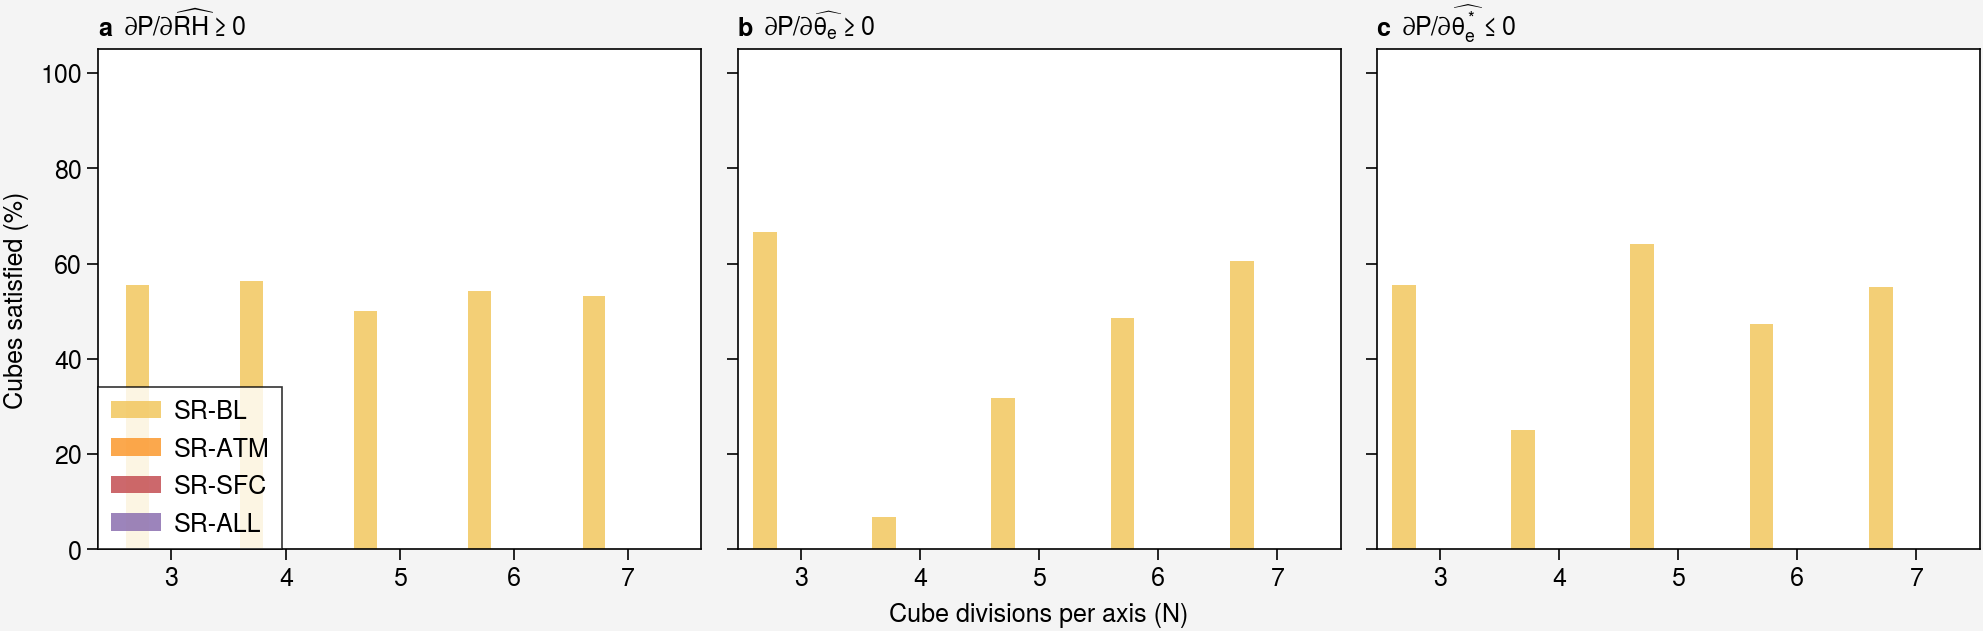

In [12]:
ncols = len(CONSTRAINTS)
fig,axs = pplt.subplots(ncols=ncols,figwidth=10,refheight=2.5,sharey=True)

barwidth = 0.8 / len(ORDER)
modelpos = np.arange(len(NCUBES))

for col,(pcname,pc) in enumerate(CONSTRAINTS.items()):
    ax = axs[col]
    for i,name in enumerate(ORDER):
        pcts = [results[name][pcname]['all'][n][0]/max(results[name][pcname]['all'][n][1],1)*100 for n in NCUBES]
        ax.bar(modelpos + (i-(len(ORDER)-1)/2)*barwidth,pcts,width=barwidth,color=COLORS[name],alpha=0.85,label=LABELS[name] if col==0 else None)
    ax.format(grid=False,xticks=modelpos,xticklabels=[str(n) for n in NCUBES],
              xlabel='Cube divisions per axis (N)',ylabel='Cubes satisfied (%)' if col==0 else None,
              ylim=(0,105),title=pc['label'])

axs[0].legend(loc='ll',ncols=1)
axs.format(abc=True,titleloc='l')
pplt.show()

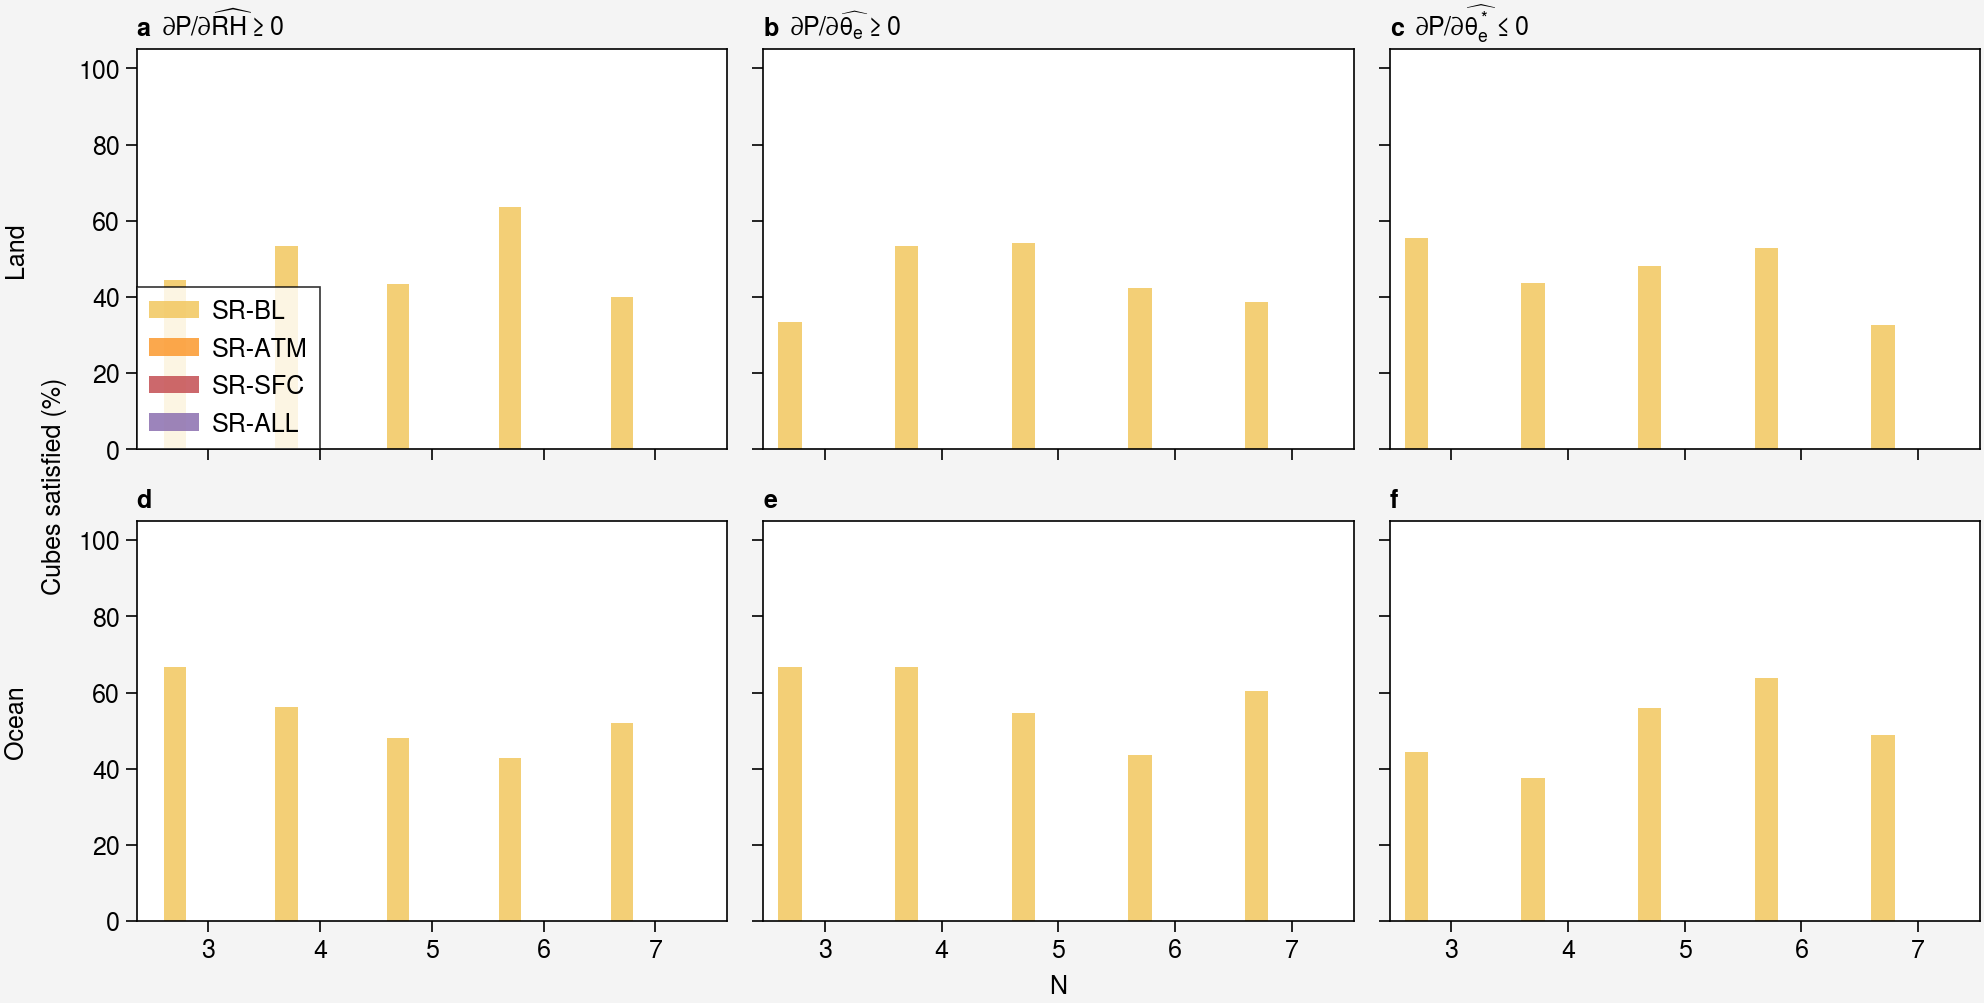

In [13]:
fig,axs = pplt.subplots(nrows=2,ncols=len(CONSTRAINTS),figwidth=10,refheight=2,sharey=True,sharex=True)
axs.format(rowlabels=['Land','Ocean'])

for col,(pcname,pc) in enumerate(CONSTRAINTS.items()):
    for row,region in enumerate(['land','ocean']):
        ax = axs[row,col]
        for i,name in enumerate(ORDER):
            pcts = [results[name][pcname][region][n][0]/max(results[name][pcname][region][n][1],1)*100 for n in NCUBES]
            ax.bar(modelpos + (i-(len(ORDER)-1)/2)*barwidth,pcts,width=barwidth,color=COLORS[name],alpha=0.85,label=LABELS[name] if row==0 and col==0 else None)
        ax.format(grid=False,xticks=modelpos,xticklabels=[str(n) for n in NCUBES],
                  xlabel='N' if row==1 else None,
                  ylabel='Cubes satisfied (%)' if col==0 else None,
                  ylim=(0,105),title=pc['label'] if row==0 else None)

axs[0,0].legend(loc='ll',ncols=1)
axs.format(abc=True,titleloc='l')
pplt.show()